In [1]:
import pandas as pd

# Load the CSV file into a structure called a DataFrame (df)
df = pd.read_csv('CustSegmentation_Tableau_input_ (1).csv')

# Look at the first 5 rows to make sure it loaded correctly
df.head()

,Unnamed: 0,Cluster,ProdCat1,ProdCat2,GROSS_TURNOVER,INVOICE_NUMBER,Main_account_name_number
0,0,3,Television and Entertainment,Music Streaming Services,364.6500,2,17566_Customer Group_1
1,1,3,Mobile Services,Mobile Plans (Prepaid),93820.4062,191,17566_Customer Group_1
2,2,3,Communication Tools,Virtual Event Hosting,11502.9356,13,17566_Customer Group_1
3,3,3,Television and Entertainment,Local TV Channels,61291.8434,21,17566_Customer Group_1
4,4,3,Gaming and eSports,Game Development Services,520.6140,1,17566_Customer Group_1


In [2]:
# Keep only rows where GROSS_TURNOVER is strictly greater than 0
df_active = df[df['GROSS_TURNOVER'] > 0]

# Print out how many rows are left compared to the original
print("Original rows:", len(df))
print("Active revenue rows:", len(df_active))

Original rows: 878190
Active revenue rows: 93168


In [3]:
# Group by Cluster and Product, then calculate sum and unique counts
prod_summary = df_active.groupby(['Cluster', 'ProdCat2']).agg(
    Gross_Turnover=('GROSS_TURNOVER', 'sum'),
    Customer_Count=('Main_account_name_number', 'nunique')
).reset_index()

# Preview our new summarized table
prod_summary.head()

,Cluster,ProdCat2,Gross_Turnover,Customer_Count
0,0,3G Services,1.611694e+03,2
1,0,4G Services,1.343100e+06,68
2,0,5G Services,1.335569e+06,37
3,0,AI-Powered Customer Support,1.029888e+05,12
4,0,AR Game Development,5.130437e+04,13


In [4]:
# 1. Sort the products within each cluster from highest revenue to lowest
prod_summary = prod_summary.sort_values(by=['Cluster', 'Gross_Turnover'], ascending=[True, False])

# 2. Get a running total sum of the turnover
prod_summary['Cumulative_Turnover_Sum'] = prod_summary.groupby('Cluster')['Gross_Turnover'].cumsum()

# 3. Find the grand total revenue for each cluster
prod_summary['Cluster_Total_Turnover'] = prod_summary.groupby('Cluster')['Gross_Turnover'].transform('sum')

# 4. Compute the final Cumulative Percentage for your X-Axis
prod_summary['Cumulative_Gross_Turnover_Pct'] = (prod_summary['Cumulative_Turnover_Sum'] / prod_summary['Cluster_Total_Turnover']) * 100

# Let's inspect the calculations
prod_summary.head(10)

,Cluster,ProdCat2,Gross_Turnover,Customer_Count,Cumulative_Turnover_Sum,Cluster_Total_Turnover,Cumulative_Gross_Turnover_Pct
163,0,TV and Entertainment Packages,5.516454e+06,12,5.516454e+06,5.518037e+07,9.997131
162,0,Sports Subscription Packages,5.046571e+06,69,1.056302e+07,5.518037e+07,19.142723
122,0,News Subscription Packages,2.714596e+06,70,1.327762e+07,5.518037e+07,24.062219
107,0,Mobile TV Services,2.248626e+06,129,1.552625e+07,5.518037e+07,28.137266
133,0,Over-the-Top (OTT) Services,2.048243e+06,74,1.757449e+07,5.518037e+07,31.849172
25,0,Cloud and Hosting Services,1.938408e+06,43,1.951290e+07,5.518037e+07,35.362030
90,0,Local TV Channels,1.618078e+06,37,2.113098e+07,5.518037e+07,38.294373
106,0,Mobile Plans (Prepaid),1.601770e+06,130,2.273275e+07,5.518037e+07,41.197163
1,0,4G Services,1.343100e+06,68,2.407585e+07,5.518037e+07,43.631180
2,0,5G Services,1.335569e+06,37,2.541141e+07,5.518037e+07,46.051551


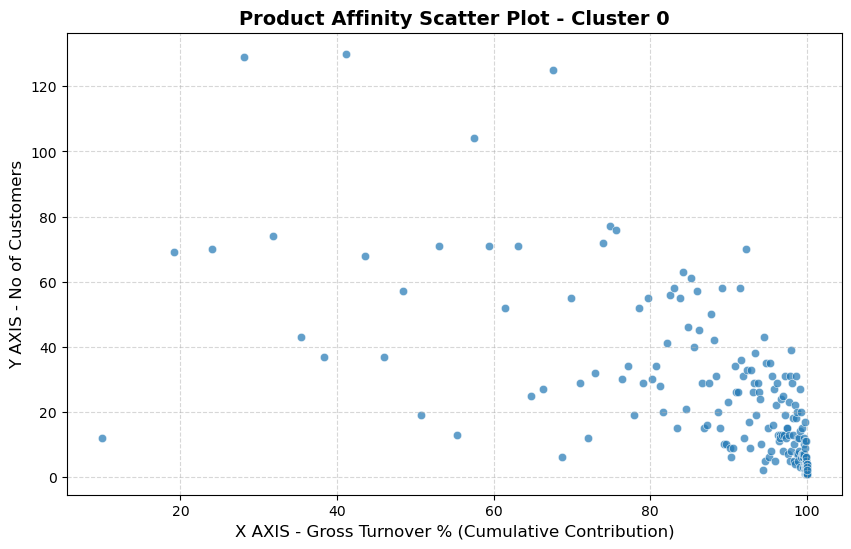

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pick which cluster you want to visualize (change this number to see others!)
target_cluster = 0
cluster_data = prod_summary[prod_summary['Cluster'] == target_cluster]

# Set the window size of the graph
plt.figure(figsize=(10, 6))

# Generate the scatter plot
sns.scatterplot(
    data=cluster_data, 
    x='Cumulative_Gross_Turnover_Pct', 
    y='Customer_Count',
    alpha=0.7
)

# Apply explicit labels matching your trainer's requirements
plt.title(f'Product Affinity Scatter Plot - Cluster {target_cluster}', fontsize=14, fontweight='bold')
plt.xlabel('X AXIS - Gross Turnover % (Cumulative Contribution)', fontsize=12)
plt.ylabel('Y AXIS - No of Customers', fontsize=12)

# Add a grid layout so it looks like a clean 2x2 grid template
plt.grid(True, linestyle='--', alpha=0.5)

# Display the graph
plt.show()

In [6]:
# Save your processed matrix table to your sidebar environment
prod_summary.to_csv('Product_Categorization_Final_Output.csv', index=False)
print("File exported successfully!")

prod_summary.head(10)

File exported successfully!
